# Lasso Model Comparison

In [12]:
import pandas as pd
import numpy as np

from sklearn import linear_model

import matplotlib.pyplot as plt

---
## Load data

### Infectivity

In [2]:
# Infectivity - constructs
data_dir='data/Infectivity/'
filename='infectivity_final_Dec15_23.csv'
cols=['new_name', 'WuG_norm_1', 'WuG_norm_2', 'WuG_norm_3', 'WuG_norm_avg']
constructs = pd.read_csv(data_dir+filename, usecols=cols)
constructs = constructs.dropna()
constructs['new_name'] = constructs['new_name'].apply(lambda x: x.capitalize() if x.islower() else x)

# Infectivity - vocs
data_dir='data/Infectivity/'
filename='infectivity_VoCs_Dec15_23.csv'
cols=['new_name', 'norm_WuG_1', 'norm_WuG_2', 'norm_WuG_3', 'norm_WuG_avg']
vocs = pd.read_csv(data_dir+filename, usecols=cols)
vocs = vocs.dropna()
vocs['new_name'] = vocs['new_name'].apply(lambda x: x.capitalize() if x.islower() else x)

# Infectivity - all
constructs = constructs.rename(columns={'new_name':'Name'})
vocs = vocs.rename(columns={'new_name':'Name', 'norm_WuG_1':'WuG_norm_1', 'norm_WuG_2':'WuG_norm_2', 'norm_WuG_3':'WuG_norm_3', 'norm_WuG_avg':'WuG_norm_avg'}) 
infectivity = pd.concat([constructs, vocs]).drop_duplicates()

# Remove avg and melt df
infectivity = infectivity.drop(columns='WuG_norm_avg')
infectivity = pd.melt(infectivity, id_vars=['Name'], value_vars=['WuG_norm_1', 'WuG_norm_2', 'WuG_norm_3'], var_name='Observation', value_name='Infectivity (WuG Norm)')
infectivity = infectivity.drop(columns='Observation')

# Mutations
data_dir = 'data/Infectivity/'
filename = 'CEPI_order_summary - SARS-CoV-2.csv'
cols = ['new_name', 'All mutations', 'Base VoC']
mutations = pd.read_csv(data_dir+filename, usecols=cols).rename(columns={'new_name':'Name'})
mutations['Name'] = mutations['Name'].apply(lambda x: x.capitalize() if x.islower() else x)    # name VoCs consistently
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(' ', ''))    # remove any spaces between mutations in the list

# Remove D614G
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace('D614G,',''))
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(',D614G',''))
mutations['All mutations'].loc[mutations['Name']=='WuG'] = None
mutations = pd.concat([mutations, pd.DataFrame([{'Name':'WT', 'All mutations':None}])])
mutations = mutations[mutations['All mutations']!='--']
print(f'{len(mutations)} sequences with known mutations')

df = infectivity.merge(mutations, on='Name', how='inner').drop_duplicates()
df = df[~pd.isna(df['Infectivity (WuG Norm)'])]
df = df.sort_values(by=['Infectivity (WuG Norm)']).reset_index(drop=True)
print(f'{len(df)} infectivity results:')

infectivity = df.copy()
del df
infectivity.head()

147 sequences with known mutations
511 infectivity results:


,Name,Infectivity (WuG Norm),Base VoC,All mutations
0,WuG_pre2020_9a,0.001778,WuhanG,"H69G,Y248D,R403T,N439R,T478K,E484V,F490R,S494R..."
1,BA.2.12.1-7a,0.002197,BA.2.12.1,"T19I,L24del,P25del,P26del,A27S,G142D,K147N,S15..."
2,BA.2.12.1-7a,0.002672,BA.2.12.1,"T19I,L24del,P25del,P26del,A27S,G142D,K147N,S15..."
3,BA.2.12.1-8a,0.002799,BA.2.12.1,"K147N,S155R,L452R,F490R,Q493S,S494R,Q498Y,K529..."
4,BA.2.12.1-5a,0.004184,BA.2.12.1,"T19I,L24del,P25del,P26del,A27S,G142D,K147N,S15..."


### Neutralization

In [3]:
# Neutralization
data_dir = 'data/Supp_Material/'
filename = 'Supp_TableS6_Neutralization_Data.csv'
neutralization = pd.read_csv(data_dir+filename)
neutralization = pd.melt(neutralization, id_vars='Name').rename(columns={'variable':'Pool', 'value':'Neutralization'})   # unpivot data
neutralization['Name'] = neutralization['Name'].apply(lambda x: x.capitalize() if x.islower() else x)   # clean up names to make sure VoCs match
neutralization['Neutralization'] = pd.to_numeric(neutralization['Neutralization'].apply(lambda x: 10 if x=='<20' else x))   # impute limits of detection

# Scale - neutralization relative to WuG WT
norm = neutralization['Neutralization'][neutralization['Name']=='WuG'].mean()
neutralization['Neutralization'] /= norm

# Rename pools
neutralization['Pool'] = neutralization['Pool'].apply(lambda x: x if x=='Bi-valent Boost' else x.split('-')[0])

# Add in Base VoC
neutralization = pd.merge(neutralization,
                          pd.read_csv('data/Supp_Material/Supp_TableS4_Infectivity_Data.csv', usecols=['Name', 'base_voc']).replace('BA.4/5', 'BA.5'),
                          on='Name')


# Log neutralization
neutralization['Neutralization - Log'] = np.log(neutralization['Neutralization'])

# Rename columns
neutralization = neutralization.rename(columns={'Name - Construct':'Name', 'base_voc':'Base VoC'})
neutralization = neutralization[['Name', 'Base VoC', 'Pool', 'Neutralization - Log']].drop_duplicates().reset_index(drop=True)

# Mutations
data_dir = 'data/Supp_Material/'
filename = 'construct_mutations.csv'
cols = ['Name', 'All mutations']
mutations = pd.read_csv(data_dir+filename, usecols=cols)
mutations['Name'] = mutations['Name'].apply(lambda x: x.capitalize() if x.islower() else x)    # name VoCs consistently
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(' ', ''))    # remove any spaces between mutations in the list

# Remove D614G
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace('D614G,',''))
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(',D614G',''))
mutations['All mutations'].loc[mutations['Name']=='WuG'] = None
mutations = pd.concat([mutations, pd.DataFrame([{'Name':'WT', 'All mutations':None}])])

mutations = mutations[mutations['All mutations']!='--']

mut_constructs = mutations['Name'].unique()

df = neutralization.merge(mutations, on='Name', how='inner').drop_duplicates()      
df['Pool ID'] = df['Pool'].map({pool:i for i, pool in enumerate(df['Pool'].unique())})
df = df.sort_values(by='Neutralization - Log').reset_index(drop=True)

print(f'{len(df)} neutralization results:')
neutralization = df.copy()
del df
neutralization.head()



1654 neutralization results:


,Name,Base VoC,Pool,Neutralization - Log,All mutations,Pool ID
0,CH.1.1,BA.2.75,Vac_Mod,-6.519872,"N764K,R346T,K147E,S477N,N440K,H655Y,S373P,G257...",2
1,BA.2.12.1-2d,BA.2.12.1,Vac_Pfiz,-6.519872,"N764K,S477N,N440K,H655Y,S373P,G339D,P25del,E48...",3
2,BA.2.12.1-2f,BA.2.12.1,Conv_WT,-6.519872,"N764K,S477N,N440K,H655Y,S373P,G339D,P25del,E48...",1
3,XBB-5a,XBB,Vac_Pfiz,-6.519872,"N764K,R346T,S477N,N440K,H655Y,S373P,P25del,E48...",3
4,XBB-5a,XBB,Vac_Mod,-6.519872,"N764K,R346T,S477N,N440K,H655Y,S373P,P25del,E48...",2


---
## Run Lasso

In [4]:
def one_hot(mutations: pd.Series):
    features = sorted(list(set(','.join(filter(None, mutations.tolist())).split(','))))
    onehot = [[1 if mut.strip() in str(muts) else 0 for mut in features] for muts in mutations]
    
    return np.array(onehot), features

In [43]:
def manhattan_lasso(ax, lasso, features, title, a):
    positions = [int(''.join([_ for _ in f if _.isdigit()])) for f in features]
    ax.plot(positions, lasso.coef_, 'o')
    
    # Annotate coefficients with absolute value greater than 0.1
    for feature, coef in zip(features, lasso.coef_):
        if abs(coef) > a:
            ax.annotate(feature, (positions[features.index(feature)], coef),
                        textcoords="offset points", xytext=(0, 5), ha='center', fontsize=7)
            
    ax.set_title(title)
    ax.set_xlabel('Position')
    ax.set_ylabel('Lasso Coefficient')

### Infectivity

31 significant features detected


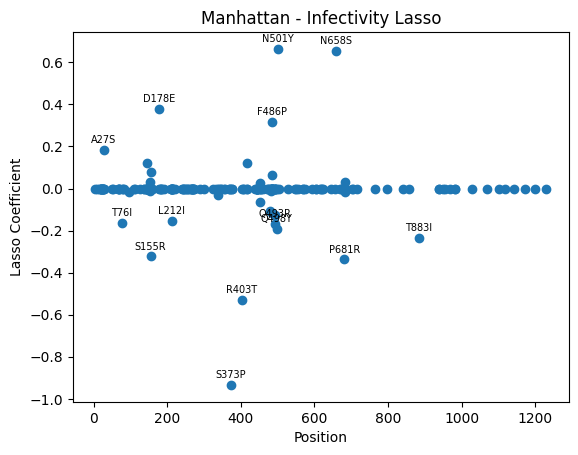

In [44]:
X, features = one_hot(infectivity['All mutations'])
Y = np.array(infectivity['Infectivity (WuG Norm)'].values)

a = 0.005

lasso = linear_model.Lasso(alpha=a)
lasso.fit(X, Y)

inf_features = [features[i] for i in lasso.coef_.nonzero()[0]]
inf_coefs = [lasso.coef_[i] for i in lasso.coef_.nonzero()[0]]
inf_int = lasso.intercept_
print(f'{len(inf_features)} significant features detected')

fig, ax = plt.subplots()
manhattan_lasso(ax, lasso, features, 'Manhattan - Infectivity Lasso', 0.15)

### Neutralization

30 significant features detected


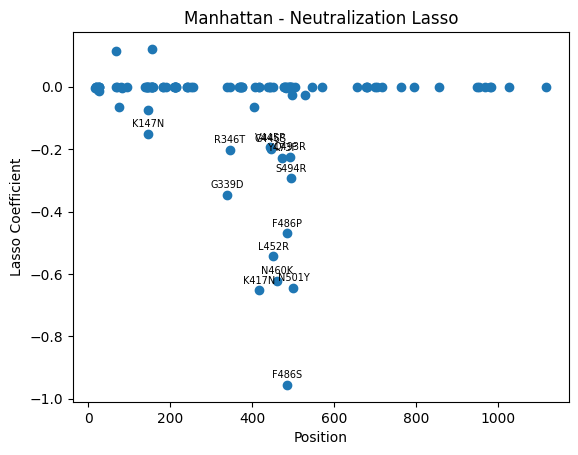

In [45]:
X, features = one_hot(neutralization['All mutations'])
Y = np.array(neutralization['Neutralization - Log'].values)

a = 0.005

lasso = linear_model.Lasso(alpha=a)
lasso.fit(X, Y)

neut_features = [features[i] for i in lasso.coef_.nonzero()[0]]
neut_coefs = [lasso.coef_[i] for i in lasso.coef_.nonzero()[0]]
neut_int = lasso.intercept_
print(f'{len(neut_features)} significant features detected')

fig, ax = plt.subplots()
manhattan_lasso(ax, lasso, features, 'Manhattan - Neutralization Lasso', 0.15)

## Save

In [7]:
inf_results = pd.DataFrame()
inf_results['Mutation'] = inf_features
inf_results['Value'] = inf_coefs
inf_results.loc[len(inf_results)] = ['Intercept', inf_int]
inf_results.to_csv('results/Lasso/infectivity.csv', index=False)

neut_results = pd.DataFrame()
neut_results['Mutation'] = neut_features
neut_results['Value'] = neut_coefs
neut_results.loc[len(neut_results)] = ['Intercept', neut_int]
neut_results.to_csv('results/Lasso/neutralization.csv', index=False)

## Visualize Results

In [25]:
def plot_manhattan(ax, df):
    ax.plot(df['Position'],
            df['Value'],
            marker='o',
            linestyle='')
    ax.set_xlabel('Position')
    ax.set_ylabel('Value')
    
    ax.tick_params(axis='x', labelrotation=90)

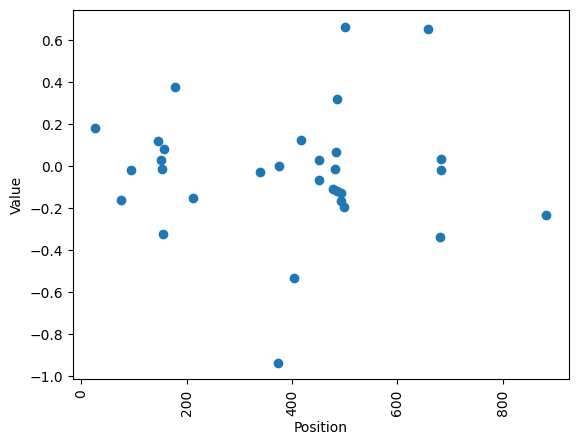

In [26]:
inf_results['Position'] = pd.to_numeric(inf_results['Mutation'].apply(lambda x: ''.join([_ for _ in x if _.isdigit()])), errors='coerce')

fig, ax = plt.subplots()
plot_manhattan(ax, inf_results)